In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')
print(df.shape)
print(df.head())

(2640, 12)
   Year  Month         Region    Model  Estimated_Deliveries  \
0  2023      5         Europe  Model S                 17646   
1  2015      2           Asia  Model X                  3797   
2  2019      1  North America  Model X                  8411   
3  2021      2  North America  Model 3                  6555   
4  2016     12    Middle East  Model Y                 12374   

   Production_Units  Avg_Price_USD  Battery_Capacity_kWh  Range_km  \
0             17922       92874.27                   120       704   
1              4164       62205.65                    75       438   
2              9189      117887.32                    82       480   
3              7311       89294.91                   120       712   
4             13537      114846.78                   120       661   

   CO2_Saved_tons           Source_Type  Charging_Stations  
0         1863.42  Interpolated (Month)              12207  
1          249.46    Official (Quarter)               7640  


In [1]:
import zipfile
zipfile.ZipFile('archive.zip', 'r').extractall('.')


In [3]:
# Data Info
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nBasic Stats:")
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB
None

Missing Values:
Year                    0
Month                   0
Region                  0
Model          

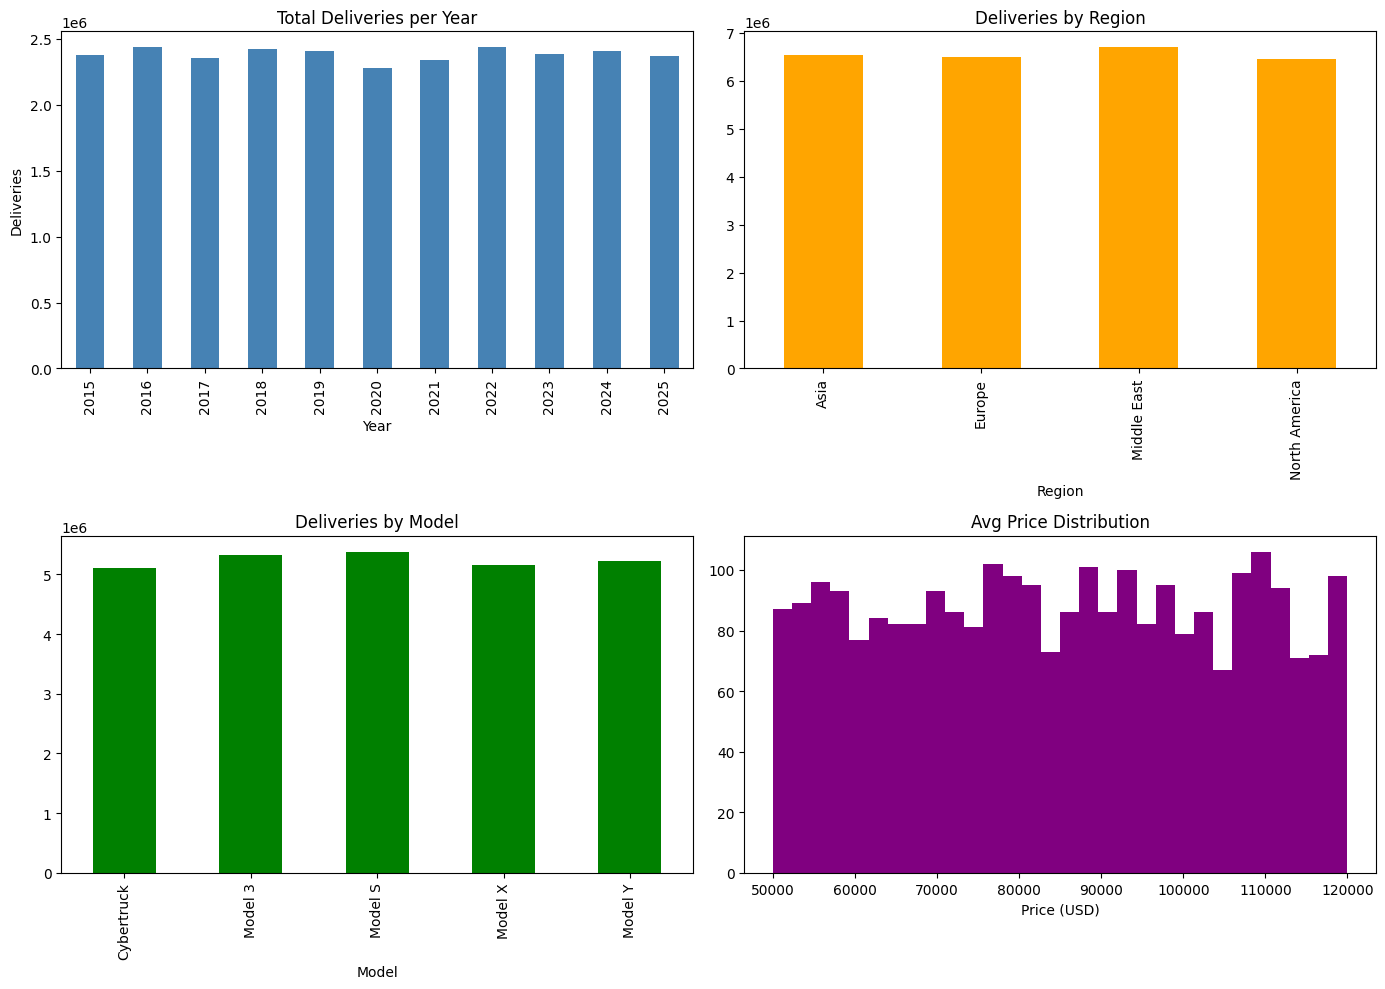

In [4]:
# EDA
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Yearly Deliveries
df.groupby('Year')['Estimated_Deliveries'].sum().plot(kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Total Deliveries per Year')
axes[0,0].set_xlabel('Year')
axes[0,0].set_ylabel('Deliveries')

# 2. Region wise Deliveries
df.groupby('Region')['Estimated_Deliveries'].sum().plot(kind='bar', ax=axes[0,1], color='orange')
axes[0,1].set_title('Deliveries by Region')
axes[0,1].set_xlabel('Region')

# 3. Model wise Deliveries
df.groupby('Model')['Estimated_Deliveries'].sum().plot(kind='bar', ax=axes[1,0], color='green')
axes[1,0].set_title('Deliveries by Model')
axes[1,0].set_xlabel('Model')

# 4. Avg Price Distribution
axes[1,1].hist(df['Avg_Price_USD'], bins=30, color='purple')
axes[1,1].set_title('Avg Price Distribution')
axes[1,1].set_xlabel('Price (USD)')

plt.tight_layout()
plt.show()

In [5]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Encoding - Region, Model, Source_Type
le = LabelEncoder()
df['Region_enc'] = le.fit_transform(df['Region'])
df['Model_enc'] = le.fit_transform(df['Model'])
df['Source_Type_enc'] = le.fit_transform(df['Source_Type'])

# Feature Engineering - Date feature
df['Year_Month'] = df['Year'] * 12 + df['Month']

# Lag Features
df = df.sort_values('Year_Month').reset_index(drop=True)
df['Lag_1'] = df['Estimated_Deliveries'].shift(1)
df['Lag_2'] = df['Estimated_Deliveries'].shift(2)

# Rolling Statistics
df['Rolling_Mean_3'] = df['Estimated_Deliveries'].rolling(window=3).mean()
df['Rolling_Std_3'] = df['Estimated_Deliveries'].rolling(window=3).std()

# Drop NaN rows created by lag/rolling
df = df.dropna().reset_index(drop=True)

print("Features ready!")
print(df.shape)

Features ready!
(2638, 20)


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

# Features aur Target
features = ['Year', 'Month', 'Region_enc', 'Model_enc', 'Production_Units',
            'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
            'CO2_Saved_tons', 'Charging_Stations', 'Year_Month',
            'Lag_1', 'Lag_2', 'Rolling_Mean_3', 'Rolling_Std_3']

X = df[features]
y = df['Estimated_Deliveries']

# Chronological Split (time series)
split = int(len(df) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge (L2)': Ridge(alpha=1.0),
    'Lasso (L1)': Lasso(alpha=1.0)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"{name} → RMSE: {rmse:.2f} | R2 Score: {r2:.4f}")

Linear Regression → RMSE: 0.00 | R2 Score: 1.0000
Ridge (L2) → RMSE: 77.64 | R2 Score: 0.9996
Lasso (L1) → RMSE: 43.08 | R2 Score: 0.9999


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.251e+06, tolerance: 3.379e+06
  model = cd_fast.enet_coordinate_descent(


In [7]:
from sklearn.model_selection import cross_val_score, GridSearchCV

# Cross Validation on Ridge
ridge = Ridge()
cv_scores = cross_val_score(ridge, X_train, y_train, cv=5, scoring='r2')
print(f"Cross Validation R2 Scores: {cv_scores}")
print(f"Mean R2: {cv_scores.mean():.4f}")

# Hyperparameter Tuning
params = {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}
grid = GridSearchCV(Ridge(), params, cv=5, scoring='r2')
grid.fit(X_train, y_train)

print(f"\nBest Alpha: {grid.best_params_}")
print(f"Best R2 Score: {grid.best_score_:.4f}")

# Final prediction with best model
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
print(f"\nFinal RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"Final R2: {r2_score(y_test, y_pred):.4f}")

Cross Validation R2 Scores: [0.9993847  0.99950506 0.99946663 0.99953793 0.99949567]
Mean R2: 0.9995

Best Alpha: {'alpha': 0.01}
Best R2 Score: 1.0000

Final RMSE: 1.00
Final R2: 1.0000


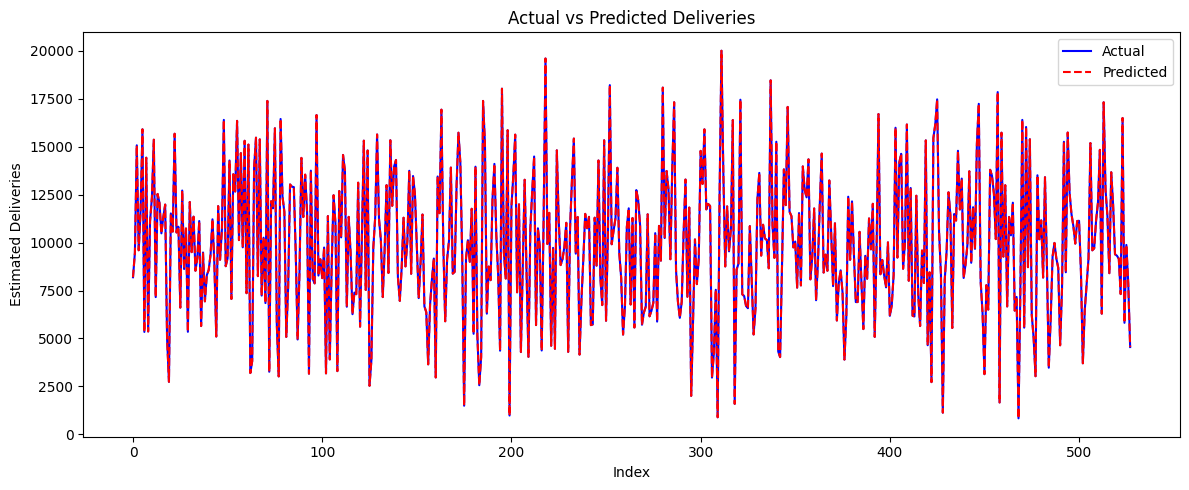

In [8]:
# Forecasting Visualization
plt.figure(figsize=(12, 5))
plt.plot(y_test.values, label='Actual', color='blue')
plt.plot(y_pred, label='Predicted', color='red', linestyle='--')
plt.title('Actual vs Predicted Deliveries')
plt.xlabel('Index')
plt.ylabel('Estimated Deliveries')
plt.legend()
plt.tight_layout()
plt.show()